In [1]:
import numpy as np 
import pandas as pd
from tqdm import tqdm

In [2]:
import os

In [3]:
data_path = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10/'
all_data = pd.concat([pd.read_parquet(data_path+f"/{split}.parquet") for split in ["train", "valid", "test"]])

In [4]:
coverage_stats = all_data[["read_name", "name", "original_label"]].groupby(["name", "original_label"]).count().reset_index()

In [5]:
unique_regions = all_data["name"].unique()

In [6]:
x = coverage_stats.groupby("name").agg("min")["read_name"].value_counts()

In [7]:
x = x.reset_index()

In [8]:
sum(x[x["read_name"]>10]["count"])

458

In [9]:
# 1. Standardize the pattern into absolute genomic coordinates
def extract_cpg_signature(row):
    start = row['trimmed_start']
    pattern = str(row['pattern'])
    return tuple((start + i, int(val)) for i, val in enumerate(pattern) if val in ('0', '1'))

# Using tqdm for pandas apply (optional, but helpful for large datasets)
tqdm.pandas(desc="Extracting Signatures")
all_data['cpg_sig'] = all_data.progress_apply(extract_cpg_signature, axis=1)

Extracting Signatures: 100%|██████████| 4637593/4637593 [00:39<00:00, 118759.97it/s]


In [10]:
df = all_data.copy()
label_col = "original_label"
num_classes = 39

In [11]:
base_counts = df.groupby(['name', 'cpg_sig', label_col]).size().unstack(fill_value=0)
base_counts = base_counts.reindex(columns=range(num_classes), fill_value=0)
base_counts = base_counts.reset_index()
base_counts["total_reads"] = base_counts[list(range(num_classes))].sum(axis=1)

In [12]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def signature_distance(sig1, sig2,length_penalty_weight=1):
    """
    Computes distance between two CpG signatures (0.0 to 2.0).
    Distance = Mismatch Rate + Length Penalty.
    """
    dict1 = dict(sig1)
    dict2 = dict(sig2)
    
    shared_pos = set(dict1.keys()).intersection(set(dict2.keys()))
    
    # If they share no CpGs, they are maximally distant
    if not shared_pos:
        return 2.0 
        
    # 1. Mismatch Rate
    mismatches = sum(1 for p in shared_pos if dict1[p] != dict2[p])
    mismatch_rate = mismatches / len(shared_pos)
    
    # 2. Length Penalty
    length_penalty = (1.0 - (len(shared_pos) / max(len(dict1), len(dict2))))*length_penalty_weight
    
    return mismatch_rate + length_penalty

def apply_normalized_knn_smoothing(base_counts, min_reads=30, max_distance=0.5, num_classes=40,length_penalty_weight=1):
    """
    Applies KNN smoothing with strict distance constraints and global 
    sequencing depth normalization.
    """
    class_cols = list(range(num_classes))
    
    # ==========================================
    # 1. Calculate Global Normalization Weights
    # ==========================================
    # Sum all reads across all regions and signatures for each class
    global_class_counts = base_counts[class_cols].sum(axis=0)
    
    # Use the median count of the present classes as the target normalization baseline
    nonzero_counts = global_class_counts[global_class_counts > 0]
    if len(nonzero_counts) == 0:
        raise ValueError("No reads found for any class in base_counts.")
        
    median_count = nonzero_counts.median()
    
    # Calculate weights (add epsilon to avoid division by zero for absent classes)
    epsilon = 1e-9
    class_weights = (median_count / (global_class_counts + epsilon)).values
    
    print(f"Calculated normalization weights. Max weight: {class_weights.max():.2f}, Min weight: {class_weights.min():.2f}")

    # ==========================================
    # 2. Region-by-Region Smoothing
    # ==========================================
    smoothed_records = []
    grouped = base_counts.groupby('name')
    
    for region, group in tqdm(grouped, desc="Smoothing Regions"):
        group = group.reset_index(drop=True)
        n_sigs = len(group)
        
        sigs = group['cpg_sig'].values
        counts_mat = group[class_cols].values.astype(float)
        total_reads = group['total_reads'].values
            
        # Precompute distance matrix for this region
        dist_mat = np.zeros((n_sigs, n_sigs))
        for i in range(n_sigs):
            for j in range(i + 1, n_sigs):
                d = signature_distance(sigs[i], sigs[j],length_penalty_weight)
                dist_mat[i, j] = d
                dist_mat[j, i] = d
                
        # Apply smoothing and normalization
        for i in range(n_sigs):
            accumulated_counts = np.zeros(num_classes)
            accumulated_total = 0
            sigs_pooled = 0
            
            if total_reads[i] >= min_reads:
                # Target already met: use exact raw counts
                accumulated_counts = counts_mat[i]
                accumulated_total = total_reads[i]
                sigs_pooled = 1
            else:
                # Target not met: borrow from valid neighbors
                neighbor_indices = np.argsort(dist_mat[i])
                
                for idx in neighbor_indices:
                    if dist_mat[i, idx] > max_distance:
                        break 
                        
                    accumulated_counts += counts_mat[idx]
                    accumulated_total += total_reads[idx]
                    sigs_pooled += 1
                    
                    if accumulated_total >= min_reads:
                        break
                        
            # --- CRITICAL STEP: Apply Global Normalization Weights ---
            normalized_counts = accumulated_counts * class_weights
            total_normalized = normalized_counts.sum()
            
            # Compute probability on the NORMALIZED pool
            if total_normalized > 0:
                prob = normalized_counts / total_normalized
            else:
                prob = np.zeros(num_classes)
                
            smoothed_records.append({
                'name': region,
                'cpg_sig': sigs[i],
                'normalized_counts': normalized_counts.tolist(),
                'soft_label': prob.tolist(),
                'raw_reads_pooled': int(accumulated_total), # Track actual physical reads 
                'total_normalized_reads': int(total_normalized),
                'num_signatures_pooled': sigs_pooled
            })
                
    return pd.DataFrame(smoothed_records)

# --- Execution ---
# mapping_df = apply_normalized_knn_smoothing(base_counts, min_reads=30, max_distance=0.5, num_classes=40)
# final_data = all_data.merge(mapping_df, on=['name', 'cpg_sig'], how='left')

In [13]:
mapping_df = apply_normalized_knn_smoothing(base_counts, min_reads=30, num_classes=39,max_distance=0,length_penalty_weight=1)

Calculated normalization weights. Max weight: 6.29, Min weight: 0.20


Smoothing Regions: 100%|██████████| 844/844 [02:28<00:00,  5.69it/s]


In [15]:
final_data = all_data.merge(mapping_df, on=['name', 'cpg_sig'], how='left')

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import ast

def plot_soft_label_distribution(df, target_dmr_ctype, target_label, labels_dict, num_classes=40):
    """
    Plots the distribution of soft label probabilities across all classes,
    using a dictionary to map class indices to biological names.
    """
    # 1. Filter the dataset
    subset = df[(df['dmr_ctype'] == target_dmr_ctype) & (df['original_label'] == target_label)].copy()
    
    if len(subset) == 0:
        print(f"No reads found for dmr_ctype='{target_dmr_ctype}' and label={target_label}")
        return
        
    print(f"Found {len(subset):,} reads for this subset. Generating plot...")

    # 2. Extract and stack the soft labels into a 2D numpy array
    try:
        soft_labels_matrix = np.vstack(subset['soft_label'].values)
    except ValueError:
        # Safely evaluate string representations of lists if necessary
        subset['soft_label'] = subset['soft_label'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
        soft_labels_matrix = np.vstack(subset['soft_label'].values)

    # 3. Set up the plot
    plt.figure(figsize=(18, 7)) # Made slightly wider to accommodate text labels
    
    ax = sns.boxplot(
        data=soft_labels_matrix, 
        color="lightgray", 
        fliersize=1,     
        linewidth=1.2,
        showfliers=True  
    )

    # 4. Highlight the target label box
    if target_label < len(ax.patches):
        box = ax.patches[target_label]
        box.set_facecolor('dodgerblue')
        box.set_edgecolor('darkblue')
        box.set_linewidth(2)

    # 5. Formatting with the dictionary mappings
    target_name = labels_dict.get(target_label, f"Class {target_label}")
    
    plt.title(
        f"Soft Label Distributions for {target_dmr_ctype} Regions\n"
        f"(Ground Truth: {target_name} [{target_label}] | Reads: {len(subset):,})", 
        fontsize=14, fontweight='bold'
    )
    plt.xlabel("Cell Type", fontsize=12)
    plt.ylabel("Probability Score", fontsize=12)
    
    # Generate the string labels for the x-axis using the dictionary
    # Fall back to the integer string if an index is missing from the dict
    x_labels = [labels_dict.get(i, str(i)) for i in range(num_classes)]
    
    # Apply the string labels and force a 90-degree rotation so they don't overlap
    plt.xticks(ticks=range(num_classes), labels=x_labels, rotation=90)
    plt.ylim(-0.05, 1.05)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Update legend to show the mapped name
    legend_elements = [
        Patch(facecolor='dodgerblue', edgecolor='darkblue', label=f'Target: {target_name}'),
        Patch(facecolor='lightgray', edgecolor='#333333', label='Other Cell Types')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

In [24]:
labels_dict = {x[1]:x[0] for x in final_data[["dmr_ctype", "dmr_ctype_label"]].drop_duplicates().to_dict(orient="split")['data']}

Found 47 reads for this subset. Generating plot...


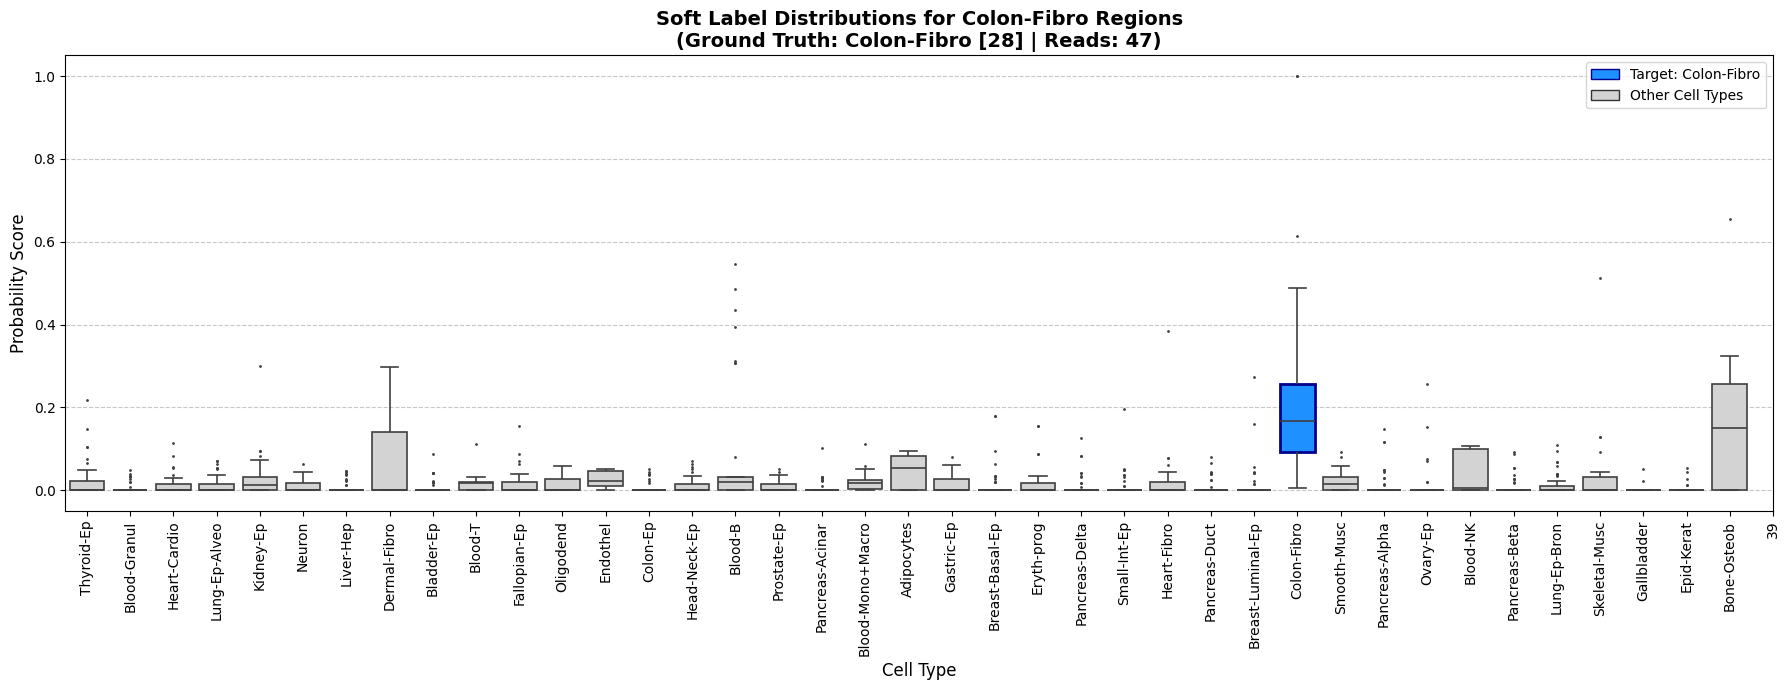

In [28]:
plot_soft_label_distribution(final_data, target_dmr_ctype="Colon-Fibro", target_label=28,labels_dict=labels_dict)

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def split_by_file_and_class(df, target_col='original_label', file_col='file', 
                            train_ratio=0.7, valid_ratio=0.15, test_ratio=0.15, 
                            random_state=42):
    """
    Splits the dataset into train, valid, and test sets.
    Prioritizes file-level isolation to prevent data leakage, 
    while EXPLICITLY guaranteeing every class is represented in all splits.
    """
    assert np.isclose(train_ratio + valid_ratio + test_ratio, 1.0), "Ratios must sum to 1.0"
    
    train_chunks, valid_chunks, test_chunks = [], [], []
    
    # Group the entire dataset by the ground truth cell type
    grouped = df.groupby(target_col)
    
    for label, group in grouped:
        # Get read counts per file for this specific cell type
        file_counts = group[file_col].value_counts().to_dict()
        files_sorted = sorted(file_counts.keys(), key=lambda k: file_counts[k], reverse=True)
        n_files = len(files_sorted)
        total_reads = sum(file_counts.values())
        
        if n_files >= 3:
            # REVISED GREEDY FILE-LEVEL ALLOCATION WITH COVERAGE OVERRIDE
            targets = {
                'train': total_reads * train_ratio,
                'valid': total_reads * valid_ratio,
                'test': total_reads * test_ratio
            }
            current_counts = {'train': 0, 'valid': 0, 'test': 0}
            allocations = {'train': [], 'valid': [], 'test': []}
            
            for i, file in enumerate(files_sorted):
                f_count = file_counts[file]
                remaining_files = n_files - i
                
                # Check which buckets still have 0 files
                empty_buckets = [b for b in targets.keys() if not allocations[b]]
                
                # FORCE COVERAGE: If we only have just enough files left to fill the empty 
                # buckets, we must abandon the ratio math and fill the empty buckets.
                if len(empty_buckets) >= remaining_files:
                    best_bucket = max(empty_buckets, key=lambda b: targets[b])
                else:
                    # Otherwise, use standard greedy: give to bucket with highest deficit
                    deficits = {k: targets[k] - current_counts[k] for k in targets}
                    best_bucket = max(deficits, key=deficits.get)
                    
                allocations[best_bucket].append(file)
                current_counts[best_bucket] += f_count
                
            train_chunks.append(group[group[file_col].isin(allocations['train'])])
            valid_chunks.append(group[group[file_col].isin(allocations['valid'])])
            test_chunks.append(group[group[file_col].isin(allocations['test'])])
            
        elif n_files == 2:
            # 2 FILES: Keep Train isolated. Split File 2 into Valid/Test.
            file1, file2 = files_sorted[0], files_sorted[1]
            
            # Put the largest file in Train
            train_chunks.append(group[group[file_col] == file1])
            
            # Split the second file between valid and test
            file2_df = group[group[file_col] == file2]
            val_prop = valid_ratio / (valid_ratio + test_ratio)
            
            val_df, test_df = train_test_split(file2_df, train_size=val_prop, random_state=random_state)
            valid_chunks.append(val_df)
            test_chunks.append(test_df)
            
        else:
            # 1 FILE: Unavoidable read-level split to ensure class coverage.
            file_df = group
            train_df, temp_df = train_test_split(file_df, train_size=train_ratio, random_state=random_state)
            
            val_prop = valid_ratio / (valid_ratio + test_ratio)
            val_df, test_df = train_test_split(temp_df, train_size=val_prop, random_state=random_state)
            
            train_chunks.append(train_df)
            valid_chunks.append(val_df)
            test_chunks.append(test_df)

    # Combine all the chunks
    df_train = pd.concat(train_chunks, ignore_index=True)
    df_valid = pd.concat(valid_chunks, ignore_index=True)
    df_test = pd.concat(test_chunks, ignore_index=True)
    
    return df_train, df_valid, df_test

In [30]:
train_df, valid_df, test_df = split_by_file_and_class(final_data,target_col='original_label')

In [32]:
new_data_path = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/SoftLabelsTrainingData_withoutpooling_hg38_mincpg_4_minlen_10/'
# os.mkdir(new_data_path)
for name, df in zip(["train", "valid", "test"], [train_df, valid_df, test_df]):
    df.to_parquet(os.path.join(new_data_path, f"{name}.parquet"), index=False)